<a href="https://colab.research.google.com/github/lleralugo/telecom-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # importar librerías

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info()   # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info()   # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info()   # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print("Cantidad de valores nulos")
print(users.isna().sum())  # Cantidad de valores nulos)
print()
print("Proporcion de valores nulos")
print(users.isna().mean()* 100)   # Proporción de valores nulos)

Cantidad de valores nulos
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporcion de valores nulos
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [ ]:
print("Cantidad de valores nulos")
print(usage.isna().sum())
print()
print("Proporcion de valores nulos")
print(usage.isna().mean()* 100)  # cantidad de nulos para usage

Cantidad de valores nulos
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporcion de valores nulos
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- **¿Qué columnas tienen valores faltantes y en qué proporción?**
    para **users** tenemos valores faltantes en "city" con una proporcion del 11.7%, y           "churn_date" de un 88% mientras en **usage** encontramos nulos en "date" con un 0.1%, en     "duration" con un 55% y en "length" con un 44%    
- **Indica qué harías: ¿imputar, eliminar, ignorar?**
    "city" (11%): revisaremos la distribucion de las datos y en base a eso imputaremos,
    "churn_date" (88%): esta la vamos a ignorar, no las eliminaremos porque posteriormente       nos pueden pedir infomacion con esta columna para segmentar y encontrar patrones con las     clientes que hicieron el churn.
    "date" (o.1%): aqui los podemos imputar, ya que no afectaria en nada al promedio, en que     caso que nos digan que es importante que se muestre toda la infomacion lo dejaremos como     nulos para no perder esas filas,
    "duration" (55%) y "length" (44%): aqui vemos una clara corelacion entre las columnas,       sus datos se complementan asi que esas las ignoraremos

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
users.describe()  # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`: podemos observar que todo esta en orden las informacion esta consecutiva, no parece que haya duplicados
- La columna `age`: aqui vemos que la media y la media son diferentes, algo esta sesgando el promedio a numeros inferiores y al obsevar el **min** podemos ver que hay un valor -999 (un sentinel) que esta afectando el promedio y necesitamos trabajar en el

In [ ]:
usage.describe() # explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`: estas dos muestran un buen funcionamiento, pero hay que ver si hay duplicados en **user_id**
- Las columnas `duration` y `length`: aqui podemos ver que el minimo en las dos es 0, puede ser un valor normal o un error, tambien el valor max en las dos columnas salen muy por fuera del percentil 75% habra que ver si estos outliers son valores reales o errores.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` : tenemos 7 ciudades diferentes y encontramos que la moda es bogota, esto nos servira porque si necesitamos imputar con la moda
- La columna `plan` : vemos que el top es los dos planes es el basico pero no con mucha diferencia

In [ ]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` : apesar de que text es el valor mas frecuente nos es por mucho y nos da una idea de la forma en la que los usarios utilizan los servivos


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- **¿En qué columnas encontraste valores inválidos o sentinels?**
   en contramos en la columna **age** un sentinal (-999), y en **duration** y **length** los    valores max salen muy por encima del percentil 75% asi que habra que validarlos
- ¿Qué acción tomarías?
  con el sentinal -999 es necesario remplazrlos por NaN y despues imputarlos por la mediana
   

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce")
users['reg_date'].head()  # completa el código

0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
(usage['date'].head())

# completa el código


0   2024-01-01 00:00:00.000000000
1   2024-01-01 00:06:30.969774244
2   2024-01-01 00:13:01.939548488
3   2024-01-01 00:19:32.909322733
4   2024-01-01 00:26:03.879096977
Name: date, dtype: datetime64[ns]

In [ ]:
# Revisar los años presentes en `reg_date` de users
print(users["reg_date"].dt.year.value_counts().sort_index())
print(f"valores nulos: {users['reg_date'].isna().sum()}")

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64
valores nulos: 0


En `reg_date`: aqui podemos ver que hay 40 valores con el año de 2026 que no deberian de estar porque nuestros tados corren hasta 2024, tendremos que eliminar estos datos ya que pueden ser errores de captura. tambien tenemos 0 nulos lo que significa que todos los valores se convirtieron


In [ ]:
print(usage['date'].dt.year.value_counts().sort_index())
print(f"valores nulos {usage['date'].isna().sum()}")
# Revisar los años presentes en `date` de usage


2024.0    39950
Name: date, dtype: int64
valores nulos 50


En `date`: aqui solo tenemos año 2024 pero hay 50 que nulos que veremos posteriormente como trabajarlos


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  si, tenemos año del 2026 que son errores y nulos en **usage**
- ¿Qué harías con ellas?
  lo mejor sera eliminarlas, son 40 valores que no afectaran el promedio o media y limpiara el data
  

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, np.nan)
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)


# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)


# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:
# Marcar fechas futuras como NA para reg_date
fechas_2026 = users['reg_date'].dt.year == 2026
users.loc[fechas_2026, 'reg_date'] = pd.NaT


print(users["reg_date"].describe())
print()
print(users["reg_date"].dt.year.value_counts().sort_index())


count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)* 100



type
text    99.927576
call     0.000000
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)* 100


type
call    99.932991
text     0.000000
Name: length, dtype: float64

**Haz doble clic aquí y escribe que tu diagnostico de nulos en `duration` y `length`**
Los valores nulos en duration y length se consideran MAR porque su ausencia depende de la variable type.
Cuando **type** = "text", los valores de **duration** son nulos, ya que los mensajes de texto no tienen duración.
Cuando **type** = "call", los valores de **length** son nulos, porque las llamadas no tienen longitud de caracteres como un mensaje de texto.
Esto indica que los nulos no son errores de captura ni datos perdidos al azar, sino que tienen una explicación lógica basada en el tipo de interacción.
Por esta razón, los valores se ignoran, ya que reemplazarlos o imputarlos introduciría información incorrecta y podría distorsionar el análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.




  

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
  "is_text": "sum",
  "is_call": "sum",
  "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})  # Renombrar columnas

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas

user_profile2 = user_profile[user_profile['reg_date'].dt.year == 2024]
print("Resumen estadístico por usuario durante el 2024")
print(user_profile2.describe())
print("\n" + "="*60)
print("Resumen estadístico por usuario durante el 2022-2023-2024")
print(user_profile.describe())



Resumen estadístico por usuario durante el 2024
            user_id          age  cant_mensajes  cant_llamadas  \
count   1330.000000  1330.000000    1330.000000    1330.000000   
mean   13332.699248    48.425564       5.500000       4.557143   
std      384.969999    17.962865       2.382293       2.140329   
min    12666.000000    18.000000       0.000000       0.000000   
25%    12999.250000    33.000000       4.000000       3.000000   
50%    13333.500000    48.000000       5.000000       4.000000   
75%    13665.750000    64.000000       7.000000       6.000000   
max    13999.000000    79.000000      16.000000      13.000000   

       cant_minutos_llamada  
count           1330.000000  
mean              24.126669  
std               19.458620  
min                0.000000  
25%               11.332500  
50%               20.325000  
75%               32.542500  
max              155.690000  

Resumen estadístico por usuario durante el 2022-2023-2024
            user_id         

In [ ]:
# Distribución porcentual del tipo de plan
print("Distribución de planes 2024:")
print(user_profile2["plan"].value_counts())
print("\nDistribución porcentual:")
print(user_profile2["plan"].value_counts(normalize=True) * 100)
print("\n" + "="*60)
print("Distribución de planes 2022-2023-2024:")
print(user_profile["plan"].value_counts())
print("\nDistribución porcentual:")
print(user_profile["plan"].value_counts(normalize=True) * 100)

Distribución de planes 2024:
Basico     873
Premium    457
Name: plan, dtype: int64

Distribución porcentual:
Basico     65.639098
Premium    34.360902
Name: plan, dtype: float64

Distribución de planes 2022-2023-2024:
Basico     2595
Premium    1405
Name: plan, dtype: int64

Distribución porcentual:
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)


**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas



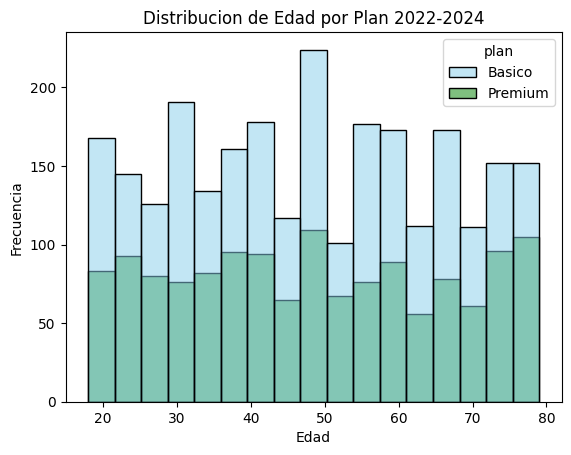

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x="age", hue='plan', palette=['skyblue','green'])
plt.title("Distribucion de Edad por Plan 2022-2024")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

💡**Insights:** resulta bastante interesante que las edades parecen distribuirce de manera relativamente uniforme. No existe un patrón evidente que indique que los usuarios del plan Básico o Premium se concentren únicamente en ciertas edades
- Distribución de las edades parece simetrica ya que no se obseva un sesgo marcado a la alta o la baja.

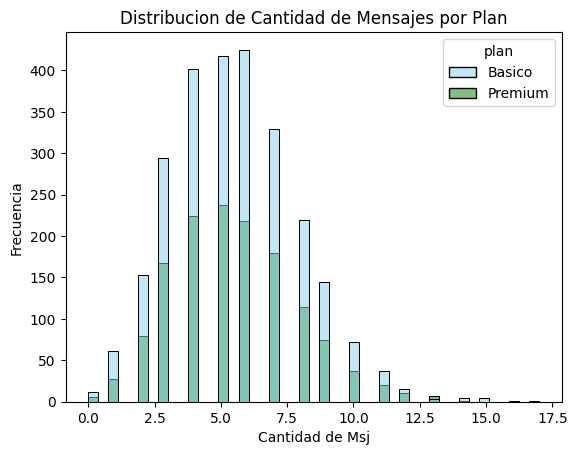

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes", hue='plan', palette=['skyblue','green'])
plt.title("Distribucion de Cantidad de Mensajes por Plan")
plt.xlabel("Cantidad de Msj")
plt.ylabel("Frecuencia")
plt.show()

💡**Insights:** No existe un patrón muy claro que indique que un plan envía muchos más mensajes que el otro; ambos muestran comportamientos similares, los usuarios de ambos planes tienden a enviar aproximadamente entre 4 y 7 mensajes, donde se concentra la mayor frecuencia
- La distribución también está sesgada a la derecha, porque la mayor parte de usuarios envía pocos mensajes y solo algunos presentan cantidades altas de mensajes.
  

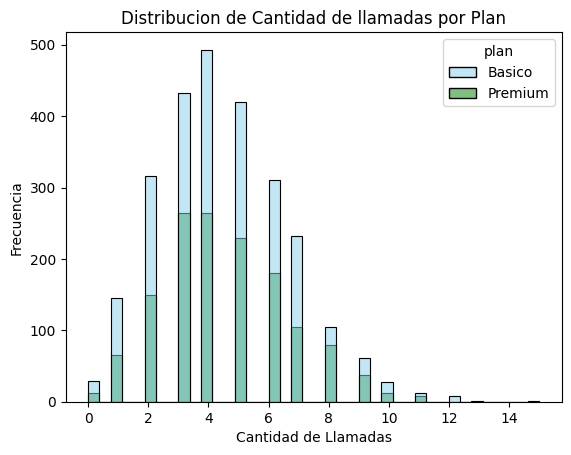

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x="cant_llamadas", hue='plan', palette=['skyblue','green'])
plt.title("Distribucion de Cantidad de llamadas por Plan")
plt.xlabel("Cantidad de Llamadas")
plt.ylabel("Frecuencia")
plt.show()

💡I**nsights:** Es muy interesante que los usuarios de ambos planes se comporten de la misma manera a pesar que el plan Premium tiene mayores beneficio, los usuarios de ambos planes tienden a realizar entre 3 y 6 llamadas, siendo ese el rango de mayor frecuencia.
- Distribución presenta un sesgo a la derecha, la mayoría de los usuarios realiza pocas llamadas y existe una cola hacia valores más altos (10, 12 o más llamadas).

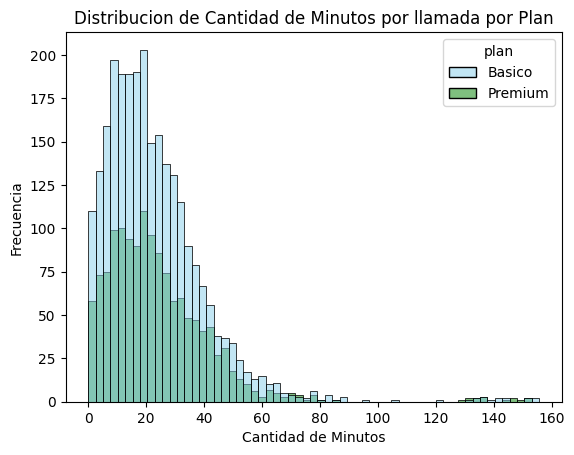

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamada", hue='plan', palette=['skyblue','green'])
plt.title("Distribucion de Cantidad de Minutos por llamada por Plan")
plt.xlabel("Cantidad de Minutos")
plt.ylabel("Frecuencia")
plt.show()

💡**Insights:** No existe un patrón fuerte que indique que un plan tenga llamadas considerablemente más largas que el otro, aunque sí aparecen algunos casos aislados con duraciones muy altas, a toda esta similitud nos llega la pregunta, ¿Entonces porque los usuarios premium elijen ser premium si se comprortan de la misma manera que los usuarios del plan basico?
- La distribución está claramente sesgada a la derecha, ya que la mayoría de usuarios acumula pocos minutos de llamada y existe una cola larga hacia valores altos (más de 100 minutos).
También se observan posibles valores atípicos (outliers) en usuarios con cantidades extremadamente altas de minutos de llamada.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.



<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.



**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

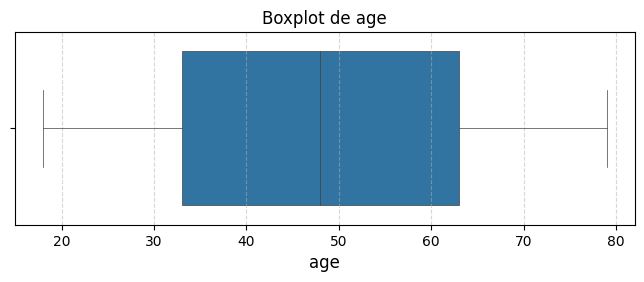

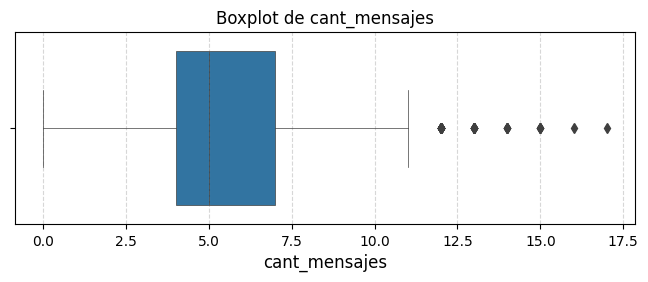

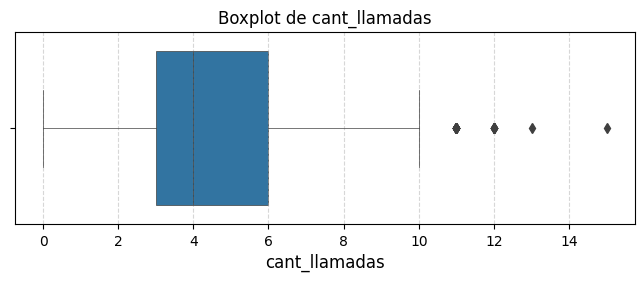

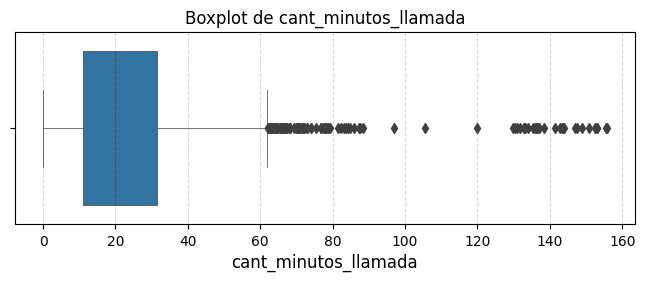

In [ ]:

# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 2.5))
    sns.boxplot(
        x=user_profile[col],
        linewidth=1-.5
    )
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col, fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()
    print(f"\n")



💡Insights:
- **Age:** no presenta valores atípicos (outliers), la distribución de edades se encuentra relativamente equilibrada y la mayoría de usuarios se concentra aproximadamente entre los 33 y 63 años.
- **cant_mensajes:** presenta algunos valores atípicos altos, ls mayoría de usuarios envía entre 4 y 7 mensajes, pero existen pocos usuarios que envían cantidades considerablemente mayores (12 a 17 mensajes).
- **cant_llamadas:** también presenta outliers , la mayor parte de usuarios realiza entre 3 y 6 llamadas, aunque algunos usuarios alcanzan valores altos de hasta 15 llamadas.
- **cant_minutos_llamada:** es la variable con mayor cantidad de outliers, la mayoría de usuarios acumula entre 10 y 30 minutos de llamada, pero existen numerosos casos extremos con más de 60 minutos e incluso superiores a 150 minutos. Además, la distribución está claramente sesgada a la derecha. A pesar de que los ouliers pueden desprenderse mucho de la mediana, si pueden ser valores completamente reales debido al comportamiento cotidiano del usurario.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3-Q1
    upper = Q3 + 1.5 * IQR
    print(f"\nOutliers en {col}:")
    print(user_profile[user_profile[col] > upper]
        .sort_values(by=col, ascending=False)
        .head()
         )




Outliers en cant_mensajes:
      user_id first_name last_name   age      city  \
1197    11197     Carlos    Torres  48.0       GDL   
3819    13819       Luis    Torres  25.0      <NA>   
2302    12302      Mateo    Torres  47.0    Bogotá   
1159    11159    Mariana    Torres  79.0    Bogotá   
2026    12026        Ana    Garcia  45.0  Medellín   

                          reg_date     plan   churn_date  cant_mensajes  \
1197 2022-11-24 18:15:23.630907728   Basico  1,72636E+18           17.0   
3819 2024-11-11 17:06:15.393848464  Premium          NaN           16.0   
2302 2023-09-23 07:55:19.129782448   Basico          NaN           15.0   
1159 2022-11-14 08:32:02.880720180   Basico          NaN           15.0   
2026 2023-07-09 18:08:54.733683424   Basico          NaN           15.0   

      cant_llamadas  cant_minutos_llamada  
1197            3.0                 24.93  
3819           11.0                 47.80  
2302            5.0                 23.26  
1159            2.0 

In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
print("=== COMPARACIÓN: LÍMITES vs VALORES MÁXIMOS ===\n")

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    max_value = user_profile[col].max()

    print(f"📊 {col.upper()}:")
    print(f"   Límite superior (IQR): {upper:.2f}")
    print(f"   Valor máximo real:     {max_value}")
    print(f"   Diferencia:            {max_value - upper:.2f}")

    outliers_count = len(user_profile[user_profile[col] > upper])
    total_users = len(user_profile)
    percentage = (outliers_count / total_users) * 100

    print(f"   Outliers detectados:   {outliers_count} ({percentage:.1f}% del total)")
    print("-" * 50)

user_profile[columnas_limites].describe()

=== COMPARACIÓN: LÍMITES vs VALORES MÁXIMOS ===

📊 CANT_MENSAJES:
   Límite superior (IQR): 11.50
   Valor máximo real:     17.0
   Diferencia:            5.50
   Outliers detectados:   46 (1.1% del total)
--------------------------------------------------
📊 CANT_LLAMADAS:
   Límite superior (IQR): 10.50
   Valor máximo real:     15.0
   Diferencia:            4.50
   Outliers detectados:   30 (0.8% del total)
--------------------------------------------------
📊 CANT_MINUTOS_LLAMADA:
   Límite superior (IQR): 61.86
   Valor máximo real:     155.69
   Diferencia:            93.83
   Outliers detectados:   109 (2.7% del total)
--------------------------------------------------


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- **cant_mensajes: mantener o no outliers, porqué?** Vamos a mantener los outliers. Aunque existen valores superiores al límite del IQR, representan solo el 1.1% del total y pueden corresponder a usuarios con una actividad de mensajería más intensa. Además, los valores máximos no son extremadamente lejanos respecto al comportamiento general.
- **cant_llamadas: mantener o no outliers, porqué?** también se podrian conservar los outliers. Los casos detectados representan únicamente el 0.8% de los datos y los valores máximos siguen siendo logicos dentro del contexto de uso normal de usuarios con alta frecuencia de llamadas.
- **cant_minutos_llamada: mantener o no outliers, porqué?** aunque presenta la mayor cantidad de outliers (2.7%) y una diferencia considerable respecto al límite superior, es recomendable mantenerlos porque pueden representar usuarios con uso intenso del servicio. No parecen algun error de captura, sino comportamientos reales de usuarios con llamadas muy largas o frecuentes.
- En general los outliers parecen corresponder a la naturalidad del comportamiento de los usuarios y no a errores en los datos, por lo que eliminarlos podría provocar pérdida de información relevante para el análisis.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def grupo_uso(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    if pd.isna(llamadas) or pd.isna(mensajes):
        return 'Error en Datos'

    if llamadas < 5 and mensajes < 5:
            return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
            return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(grupo_uso, axis=1)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def grupo_edad(row):
    edad = row['age']

    if pd.isna(edad):
        return 'Error de Datos'

    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(grupo_edad, axis=1)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

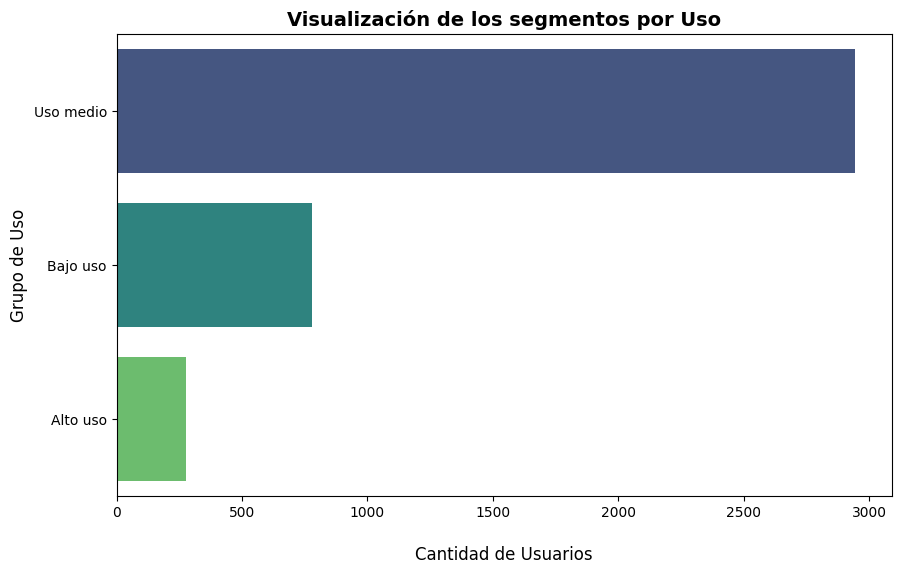

In [ ]:
# Visualización de los segmentos por uso
datos_limpios = user_profile[user_profile['grupo_uso'] != 'Error en Datos']

plt.figure(figsize=(10, 6))
sns.countplot(data=datos_limpios, y='grupo_uso',
             order=datos_limpios['grupo_uso']
             .value_counts().index, palette='viridis')
plt.title("Visualización de los segmentos por Uso", fontsize=14, fontweight='bold')
plt.xlabel("\nCantidad de Usuarios", fontsize=12)
plt.ylabel("Grupo de Uso", fontsize=12)
plt.show()

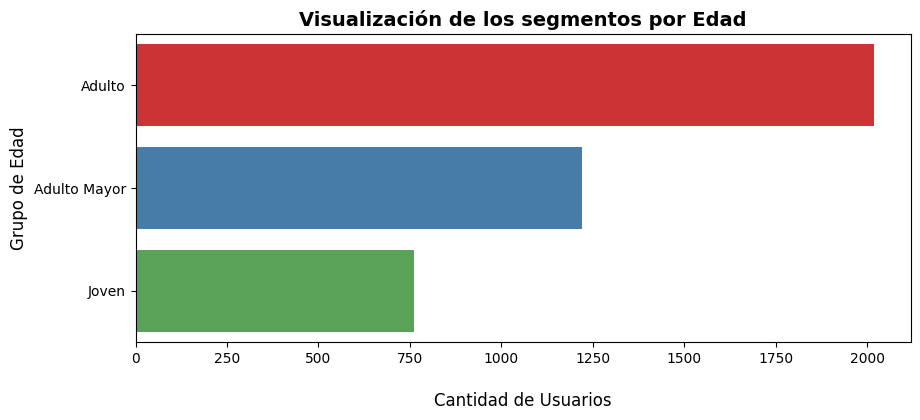

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(10, 4))
sns.countplot(data=user_profile, y='grupo_edad',
             order=user_profile['grupo_edad']
             .value_counts().index, palette='Set1')
plt.title("Visualización de los segmentos por Edad", fontsize=14, fontweight='bold')
plt.xlabel("\nCantidad de Usuarios", fontsize=12)
plt.ylabel("Grupo de Edad", fontsize=12)
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron valores faltantes representados incorrectamente con el símbolo ? en columnas como city, los cuales fueron transformados a valores nulos (NA) para permitir un análisis correcto.
- Se detectaron fechas inconsistentes en reg_date, incluyendo registros correspondientes al año 2026, los cuales fueron tratados como datos inválidos y convertidos en valores nulos.
Las columnas duration y length presentaban una gran cantidad de nulos; sin embargo, se confirmó que estos eran valores MAR (Missing At Random), ya que dependían directamente del tipo de interacción (type):
    - los mensajes de texto no tienen duración (duration)
    - las llamadas no tienen longitud de caracteres (length)
- También se detectaron valores atípicos (outliers) en:
    - cantidad de mensajes
    - cantidad de llamadas
    - minutos de llamadas.
        - No obstante, estos fueron conservados debido a que representan comportamientos reales de usuarios intensivos y no errores de captura.


🔍 **Segmentos por Edad**
- El segmento con mayor cantidad de usuarios corresponde a los Adultos, convirtiéndose en el grupo predominante dentro de la plataforma.
- Los Adultos Mayores representan el segundo grupo más importante, mostrando una participación relevante en el servicio.
- El grupo de Jóvenes es el menos numeroso, lo que sugiere una menor adopción del servicio en edades más tempranas.
- La distribución muestra que la base de clientes está concentrada principalmente en usuarios adultos con patrones de consumo moderados.


📊 **Segmentos por Nivel de Uso**
- La mayoría de usuarios pertenece al segmento de Uso medio, indicando que el comportamiento dominante consiste en un uso equilibrado de llamadas y mensajes.
- El grupo de Bajo uso representa una proporción menor pero significativa, posiblemente asociado a usuarios ocasionales o con planes limitados.
- El segmento de Alto uso es reducido, aunque estratégico para el negocio debido a su mayor consumo de servicios.
- Los usuarios con alto uso presentan mayores cantidades de mensajes, llamadas y minutos acumulados, lo que podría representar oportunidades de monetización y planes premium.



➡️ Esto sugiere que
- ConnectaTel tiene una base de clientes relativamente estable, concentrada principalmente en usuarios adultos con hábitos de uso moderados.
- Existe un pequeño grupo de usuarios intensivos que podría beneficiarse de planes especializados con mayores beneficios o servicios premium.
- La presencia de usuarios de bajo uso también abre oportunidades para estrategias de retención mediante planes económicos o promociones personalizadas.
- Los patrones detectados indican que el comportamiento de consumo no es homogéneo, por lo que la segmentación puede ayudar a mejorar la personalización de ofertas y la experiencia del cliente.


💡 **Recomendaciones**
- Diseñar planes diferenciados según el nivel de uso:
    - planes económicos para usuarios de bajo uso
    - planes intermedios para el segmento mayoritario
    - planes premium para usuarios intensivos
- Implementar campañas dirigidas al segmento joven para aumentar la adopción del servicio en edades tempranas.
- Aprovechar la segmentación para personalizar promociones, beneficios y estrategias de fidelización.
- Monitorear continuamente a los usuarios con alto consumo para detectar oportunidades comerciales y prevenir posibles problemas de saturación o abuso del servicio.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`